In [1]:
using Pkg
Pkg.activate("TASEP")
#Pkg.instantiate()
include("./modules/transcription.jl")

  Activating project at `C:\Users\ChemeGrad2021\Documents\Braatz Group\MRNA Synthesis\TASEP\TASEP`


plotparametricellipse (generic function with 1 method)

<h1>Setup (Don't change these lines)<h1>

In [3]:
#Basic parameters (from Stover et al, 2023)
k_on = 10^2.30 #P-DNA binding (hours^-1 nM^-1)
k_off = 10^3.74 #P-DNA binding (inverse hours)
k_i = 10^3.61 #Initiation rate (inverse hours)
k_e = 10^5.20 #Elongation rate (inverse hours)

#Basic pausing parameters (Klumpp and Hwa, 2008)
τ = 1/3600 #Pausing time (hours)
f = 0.1*3600 #Pausing frequency (inverse hours)

#Basic T7 RNA polymerase size parameter (My best guess + Klumpp and Hwa, 2008)
L = 25

##Key difference from Fluc##
#Basic sequence parameter 
N_all = 983;

##### Composite parameters (see overleaf derivation)
println("k_i = "*string(round(k_i; digits = 2))*" /hr")

α = 1+N_all* k_i/k_e     #Dimless
println("α = "*string(round(α; digits = 2)))

K = (k_off+k_i)/k_on     #nM
println("K = "*string(round(K; digits = 2))*" nM")

β = L*k_i^2/(k_e*k_on)   #Dimless
println("β = "*string(round(β; digits = 2)))

θ = k_off/k_on;          #nM
println("θ = "*string(round(θ; digits = 2))*" nM")

γ = k_i*f*τ^2/(1+f*τ)    #Dimless
println("γ = "*string(round(γ; digits = 2)))

p_initlimited = ComponentVector((k_i = k_i, K = K))
p_initelongation = ComponentVector((k_i = k_i, K = K, α = α))
p_basicTASEP = ComponentVector((k_i = k_i, K = K, α = α, β = β))
p_longTASEP = ComponentVector((k_i = k_i, K = K, α = α, β = β, γ = γ, θ = θ));

initiationlimited = InitiationLimitedModel()
initiationelongation = InitiationElongationModel()
basicTASEP = BasicTASEPModel()
longTASEP = LPTASEPModel();

p_base = ComponentVector((k_on = k_on, k_off = k_off, k_i = k_i, k_e = k_e, L = L, f = f, τ = τ, N_all = N_all))
p_composite = ComponentVector((k_i = k_i, α = α, γ = γ, L = L, N_all = N_all, k_off = k_off, k_on = k_on))

plott = 0.1
plotD = 10
plotP = 300;

modellist = [initiationlimited,initiationelongation,basicTASEP,longTASEP]
modelnamelist = ["Initiation limited","Initiation-elongation","Basic TASEP","Long Pause TASEP"]
modelcolorlist = [:Blues,:Greens,:Purples,:OrRd];

k_i = 4073.8 /hr
α = 26.27
K = 47.96 nM
β = 13.12
θ = 27.54 nM
γ = 0.1


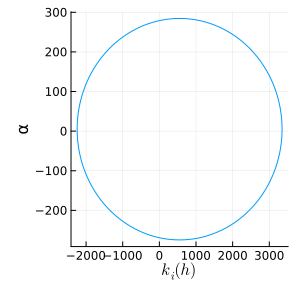

In [28]:
#First we are designing a extrmely large prior covariance (using prior = zeros(2,2) leads to numerical overshoot problems)
p_hypothesis = ComponentVector((k_i = 552.4761133478055, α = 983/2117*10.638962561438944, γ = γ, L = L, N_all = N_all, k_off = k_off, k_on = k_on))
p_thinhypothesis = [552.4761133478055, 983/2117*10.638962561438944]
eGFPpriorcov = [[1000000,0] [0,10000]]
plteGFPprior = plotparametricellipse(p_thinhypothesis,eGFPpriorcov)
display(plteGFPprior)

In [22]:
function relativenoise(T7,DNA,param,base_params;eta = 0.1)
    DP = [DNA,T7]'
    eta*modelprediction(testmodel,param, DP, base_params)[1]
end
constantnoise = (T7,DNA,param,base_params)-> 1.0

#Performing optimization for MBDOE
nexperiments = 2
initguess = [50,10,100,200]
(minf,minx,ret) = multistartMBDOEoptimization(initiationelongation,p_thinhypothesis, initguess, p_base,priormatrix = inv(eGFPpriorcov),npoints = 10000,upperDNA = 60.0,upperP = 515.0, noise = constantnoise)
println(minf)
mbdoeDP = reshape(minx,(nexperiments,2))

got 88.15073044496482 at [60.0, 60.0, 514.9999999999998, 202.10659336623047] (returned FTOL_REACHED)
88.15073044496482

2×2 Matrix{Float64}:
 60.0  515.0
 60.0  202.107

got 0.0 at [568.6507157246384, 5.453609674533119] (returned FTOL_REACHED)


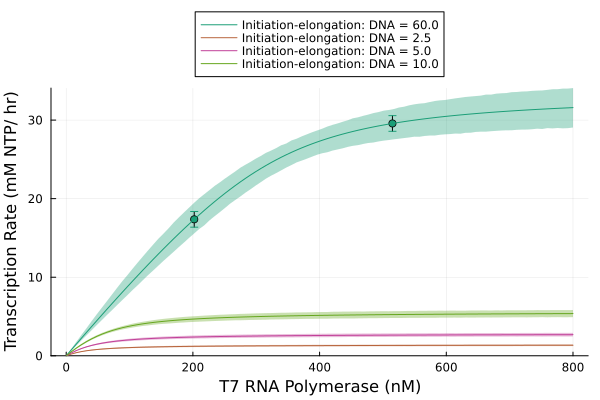

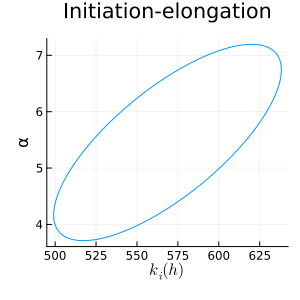

In [29]:
#Validating MBDOE strategy using Monte Carlo fitting

DPinputs = mbdoeDP

truemodelindex = 2
truemodel = modellist[truemodelindex]
truemodelname = modelnamelist[truemodelindex]
extraDNA = [2.5,5,10]


experimentalnoise = 1e-0*ones(length(DPinputs[:,1]))
npoints = 10000
normalizexaxis = false
normalizeyaxis = false

(plt,syntheticdata,DPinputs) = generateplotsyntheticdata(truemodel,p_hypothesis,DPinputs,normalizexaxis = normalizexaxis, normalizeyaxis = normalizeyaxis, noise = experimentalnoise, modelname= truemodelname, color = :Dark2_5, extraDNA = extraDNA)

(p_null,p_thintrue,truecov) = multistartoptimizeparams(truemodel, syntheticdata, DPinputs, experimentalnoise, p_base, npoints = npoints)
plotmodelprediction!(plt,truemodel,p_thintrue,truecov,p_base,DPinputs,normalizexaxis = normalizexaxis,normalizeyaxis =normalizeyaxis, modelname = truemodelname, maximumT7 = 800, color =  :Dark2_5, showuncertainty = true, extraDNA = extraDNA)
plot!(legend = :outertop, ylims = (0,Inf))
display(plt)
pltelps1 = plotparametricellipse(p_thintrue,truecov,title = truemodelname)
display(pltelps1)